In [30]:
import os
import datetime as dt
import pandas as pd
import numpy as np

from ochre import Dwelling
from ochre.utils import default_input_path

# Import OCHRE's internal schedule names so we can filter safely
from ochre.utils.schedule import ALL_SCHEDULE_NAMES 

#########################################
# 1. USER SETTINGS & EFFICIENCY
#########################################
level = 9
LVL = {1:0, 2:0.14, 3:0.29, 4:0.43, 5:0.57, 6:0.71, 7:0.857, 8:1, 9:30}

EFF_BASELINE = LVL[9] 
EFF_LOAD = LVL[9]
EFF_SHED = LVL[level]

Start = dt.datetime(2018, 1, 11, 0, 0)
Duration = 1  
t_res = 1     

# HPWH Control Params (F)
TbaselineF, TdeadbandF = 130, 7
Tcontrol_SHEDF, Tcontrol_dbF = 125, 7
Tcontrol_LOADF, Tcontrol_LOADdeadbandF = 130, 2
Tinit = 130

# Paths
inputXML = r'\bldg0002631-up06'
weather = 'USA_OR_Portland.Intl.AP.726980_TMY3.epw'

def f_to_c(f): return (f - 32) * 5/9
def f_to_c_db(f): return f * 5/9

Tcontrol_SHEDC, Tcontrol_deadbandC = f_to_c(Tcontrol_SHEDF), f_to_c_db(Tcontrol_dbF)
Tcontrol_LOADC, Tcontrol_LOADdeadbandC = f_to_c(Tcontrol_LOADF), f_to_c_db(Tcontrol_LOADdeadbandF)
TbaselineC, TdeadbandC = f_to_c(TbaselineF), f_to_c_db(TdeadbandF)
TinitC = f_to_c(Tinit)

#########################################
# 2. FILE PREP & SAFE FILTERING
#########################################
original_sched_file = os.path.join(default_input_path, "Input Files" + inputXML, 'schedules.csv')
filtered_sched_file = os.path.join(default_input_path, "Input Files" + inputXML, 'filtered_schedules.csv')

def removeItems(filename_path):
    df_sched = pd.read_csv(filename_path)
    
    # This prevents the KeyError by ensuring only valid OCHRE schedules pass through
    valid_schedule_names = set(ALL_SCHEDULE_NAMES.keys())
    filtered_columns = [col for col in df_sched.columns if col in valid_schedule_names]
    dropped_columns = [col for col in df_sched.columns if col not in filtered_columns]
    
    print("\u274c Dropped:", dropped_columns)
    
    df_sched_filtered = df_sched[filtered_columns]
    df_sched_filtered.to_csv(filtered_sched_file, index=False)
    return filtered_sched_file, df_sched_filtered

# Create the clean schedule file!
filtered_sched_file, df_schedule = removeItems(original_sched_file)

#########################################
# 3. MANUAL SCHEDULE & CONTROL LOGIC
#########################################
my_randomized_schedule = {
    'M_LU_time': '02:00', 'M_LU_duration': 2,
    'M_S_time': '04:00', 'M_S_duration': 20, 
    'E_ALU_time': '16:00', 'E_ALU_duration': 0,
    'E_S_time': '17:00', 'E_S_duration': 0
}

def determine_hpwh_control(sim_time, sched_cfg):
    # Base signal includes the new Efficiency parameters
    ctrl_signal = {'Water Heating': {'Setpoint': TbaselineC, 'Deadband': TdeadbandC, 
                                     'Load Fraction': 1, 'Efficiency Coefficient': EFF_BASELINE}}
    base_date = sim_time.date()
    
    def get_range(prefix):
        s = pd.to_datetime(f"{base_date} {sched_cfg[f'{prefix}_time']}")
        return s, s + pd.Timedelta(hours=sched_cfg[f'{prefix}_duration'])

    ranges = {k: get_range(k) for k in ['M_LU', 'M_S', 'E_ALU', 'E_S']}
    
    if (ranges['M_LU'][0] <= sim_time < ranges['M_LU'][1] or ranges['E_ALU'][0] <= sim_time < ranges['E_ALU'][1]):
        ctrl_signal['Water Heating'].update({'Setpoint': Tcontrol_LOADC, 'Deadband': Tcontrol_LOADdeadbandC, 'Efficiency Coefficient': EFF_LOAD})
    elif (ranges['M_S'][0] <= sim_time < ranges['M_S'][1] or ranges['E_S'][0] <= sim_time < ranges['E_S'][1]):
        ctrl_signal['Water Heating'].update({'Setpoint': Tcontrol_SHEDC, 'Deadband': Tcontrol_deadbandC, 'Efficiency Coefficient': EFF_SHED})
    
    return ctrl_signal

#########################################
# 4. SIMULATION EXECUTION 
#########################################
hpxml_path = os.path.join(default_input_path, "Input Files" + inputXML, 'in.XML')
weather_path = os.path.join(default_input_path, "Weather", weather)

dwelling_args = {
    "start_time": Start, 
    "time_res": dt.timedelta(minutes=t_res), 
    "duration": dt.timedelta(days=Duration),
    "hpxml_file": hpxml_path,         
    "hpxml_schedule_file": filtered_sched_file, # Fed the safely filtered schedule
    "weather_file": weather_path, 
    "verbosity": 7,
    "save_results": False,            
    "Equipment": {
        "Water Heating": {
            "Initial Temperature (C)": TinitC, 
            "hp_only_mode": False, 
            "Max Tank Temperature (C)": 70, 
            "Upper Node": 3, 
            "Lower Node": 10, 
            "Upper Node Weight": 0.75,
            "Efficiency Coefficient": EFF_BASELINE # Initialize with base efficiency
        }
    }
}

# Initialize and run
print("Initializing Dwelling...")
sim_dwelling = Dwelling(name="House_Sim", **dwelling_args)

print("Running control loop...")
for sim_time in sim_dwelling.sim_times:
    control_cmd = determine_hpwh_control(sim_time, my_randomized_schedule)
    sim_dwelling.update(control_signal=control_cmd)

df_results, _, _ = sim_dwelling.finalize()
print("\n\nSimulation complete!")

❌ Dropped: ['hot_tub_pump', 'hot_tub_heater']
Initializing Dwelling...
2026-05-04 15:38:14.602833 - House_Sim at 2018-01-11 00:00:00: Initializing House_Sim (OCHRE v0.9.1)
2026-05-04 15:38:15.147193 - House_Sim at 2018-01-11 00:00:00: Dwelling Initialized
Running control loop...
2026-05-04 15:38:18.651944 - House_Sim at 2018-01-12 00:00:00: Simulation complete, time series results saved in memory (not to a file)


Simulation complete!


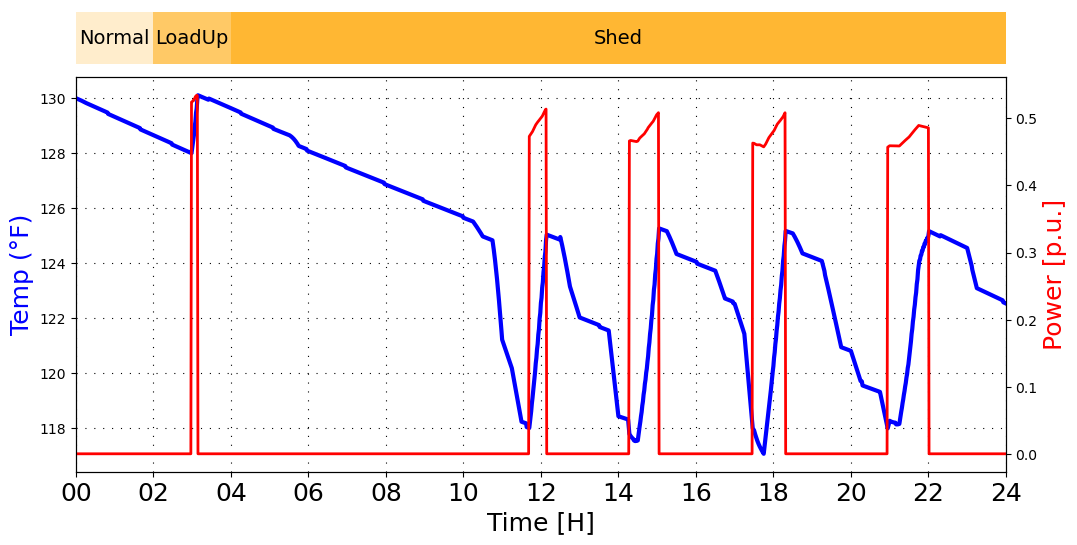

In [31]:
import os
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter
from ochre import Dwelling
from ochre.utils import default_input_path
from ochre.utils.schedule import ALL_SCHEDULE_NAMES
from datetime import timedelta, datetime


A=18

results_for_bars = {'': [2, 2, 20]}
words = ['Normal', 'LoadUp', 'Shed']

#########################################
# 4. MANUAL BARS FUNCTION
#########################################
def bars(ax, results, category_names):
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    
    alpha_map = {'Normal': 0.2, 'LoadUp': 0.6, 'Shed': 0.8, 'ALU': 1, 'Level 9': 0.8}
    Alpha = [alpha_map.get(word, 0.5) for word in category_names]
    
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_yticks([])
    ax.set_xlim(0, 24)
    
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(False)
    
    for i, colname in enumerate(category_names):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, color='orange', edgecolor='none', alpha=Alpha[i])
        for rect in rects:
            if rect.get_width() > 0.6:
                ax.text(rect.get_x() + rect.get_width()/2, rect.get_y() + rect.get_height()/2,
                        category_names[i], ha='center', va='center', color='black', fontsize=A-4)

#########################################
# 5. FINAL PLOT (Using df_results)
#########################################
fig, (ax_bars, ax_control) = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios':[1, 7]})
fig.subplots_adjust(hspace=0.05)

bars(ax_bars, results_for_bars, words)

# Identify columns in df_results
temp_col = 'Water Heating Control Temperature (C)'
pwr_col = 'Water Heating Electric Power (kW)'

hours = df_results.index.hour + df_results.index.minute / 60
ax2 = ax_control.twinx()

ax_control.plot(hours, (df_results[temp_col]*9/5+32), color='blue', linewidth=3, label='Tank Temp.')
ax2.plot(hours, df_results[pwr_col]/1, color='red', linewidth=2, label='Power') # divide by N

ax_control.set_ylabel("Temp (°F)", color='blue', fontsize=A)
ax2.set_ylabel("Power [p.u.]", color='red', fontsize=A)
ax_control.set_xlabel("Time [H]", fontsize=A)
ax_control.set_xlim(0, 24)
ax_control.set_xticks(range(0, 25, 2))
ax_control.set_xticklabels([f"{h:02d}" for h in range(0, 25, 2)], fontsize=A)
ax_control.grid(True, linestyle=(0, (1, 7)), color='black')

plt.show()

In [32]:
def create_formatted_event_matrix_with_modes(df, temp_col, pwr_col, sched_cfg):
    # 1. Setup Data
    pwr_w = df[pwr_col] * 1000
    temp_f = (df[temp_col] * 9/5 + 32).round(0)
    
    df_events = pd.DataFrame(index=df.index, columns=['HP ON', 'HP OFF', 'ER ON', 'ER OFF'], dtype=float)
    
    # 2. Detect Edges (same as before)
    hp_active = (pwr_w >= 100) & (pwr_w < 1000)
    er_active = pwr_w >= 4000
    
    hp_on_mask = hp_active & ~hp_active.shift(1, fill_value=False)
    hp_off_mask = ~hp_active & hp_active.shift(1, fill_value=False)
    er_on_mask = er_active & ~er_active.shift(1, fill_value=False)
    er_off_mask = ~er_active & er_active.shift(1, fill_value=False)
    
    df_events.loc[hp_on_mask, 'HP ON'] = temp_f
    df_events.loc[hp_off_mask, 'HP OFF'] = temp_f
    df_events.loc[er_on_mask, 'ER ON'] = temp_f
    df_events.loc[er_off_mask, 'ER OFF'] = temp_f
    
    # 3. Filter to only rows with events
    event_matrix = df_events.dropna(how='all').copy()

    # 4. Add the MODE logic
    def get_mode(timestamp):
        # Convert schedule times to comparable timestamps for that specific day
        base_date = timestamp.date()
        
        def to_dt(time_str):
            return pd.to_datetime(f"{base_date} {time_str}")

        # Check Load Up
        m_lu_start = to_dt(sched_cfg['M_LU_time'])
        e_alu_start = to_dt(sched_cfg['E_ALU_time'])
        if (m_lu_start <= timestamp < m_lu_start + pd.Timedelta(hours=sched_cfg['M_LU_duration'])) or \
           (e_alu_start <= timestamp < e_alu_start + pd.Timedelta(hours=sched_cfg['E_ALU_duration'])):
            return 'LoadUp'
        
        # Check Shed
        m_s_start = to_dt(sched_cfg['M_S_time'])
        e_s_start = to_dt(sched_cfg['E_S_time'])
        if (m_s_start <= timestamp < m_s_start + pd.Timedelta(hours=sched_cfg['M_S_duration'])) or \
           (e_s_start <= timestamp < e_s_start + pd.Timedelta(hours=sched_cfg['E_S_duration'])):
            return 'Shed'
        
        return 'Normal'

    # Apply the mode helper to the index
    event_matrix['Mode'] = [get_mode(t) for t in event_matrix.index]
    
    # 5. Format and return
    return event_matrix.fillna('....')

# To run it, pass your 'my_schedule' or 'sched' dictionary:
event_table = create_formatted_event_matrix_with_modes(df_results, temp_col, pwr_col, my_randomized_schedule)
print(event_table.to_string())

                     HP ON HP OFF ER ON ER OFF    Mode
Time                                                  
2018-01-11 02:59:00  128.0   ....  ....   ....  LoadUp
2018-01-11 03:09:00   ....  130.0  ....   ....  LoadUp
2018-01-11 11:42:00  118.0   ....  ....   ....    Shed
2018-01-11 12:09:00   ....  125.0  ....   ....    Shed
2018-01-11 14:17:00  118.0   ....  ....   ....    Shed
2018-01-11 15:03:00   ....  125.0  ....   ....    Shed
2018-01-11 17:28:00  118.0   ....  ....   ....    Shed
2018-01-11 18:19:00   ....  125.0  ....   ....    Shed
2018-01-11 20:57:00  118.0   ....  ....   ....    Shed
2018-01-11 22:01:00   ....  125.0  ....   ....    Shed
